<a href="https://colab.research.google.com/github/amarisgreat/BioFlock/blob/main/pose_classifier_v2_1_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install timm albumentations scikit-learn seaborn torch torchvision tqdm torch_optimizer


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import timm
import albumentations as A
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from albumentations.pytorch import ToTensorV2
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report
from tqdm import tqdm
from PIL import Image
from sklearn.model_selection import train_test_split


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/pose_classifier_data/my_image_labels.csv")
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])
print(train_df.head())


                        image_path  label
582   train/healthy_chicken_47.jpg      1
511  train/healthy_chicken_271.jpg      1
647  train/slipped_tendons_105.jpg      0
535  train/healthy_chicken_293.jpg      1
936   train/slipped_tendons_78.jpg      0


In [ ]:
class PoseDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = os.path.join(self.img_dir, self.df.iloc[idx, 0])
        image = Image.open(img_name).convert("RGB")
        label = int(self.df.iloc[idx, 1])

        if self.transform:
            image = self.transform(image=np.array(image))["image"]

        return image, label


In [ ]:
train_transform = A.Compose([
    A.Resize(380, 380),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomBrightnessContrast(p=0.2),
    A.Affine(scale=(0.9, 1.1), translate_percent=(0.05, 0.05), rotate=(-15, 15), p=0.5),
    A.GaussianBlur(p=0.2),
    A.CoarseDropout(max_holes=6, min_holes=1, min_height=30, min_width=30, p=0.5),
    A.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
    ToTensorV2(),
])


val_transform = A.Compose([
    A.Resize(380, 380),
    A.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
    ToTensorV2(),
])


<ipython-input-6-a7e7df34d074>:8: UserWarning: Argument(s) 'max_holes, min_holes, min_height, min_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=6, min_holes=1, min_height=30, min_width=30, p=0.5),


In [ ]:
batch_size = 32
num_workers = min(2, os.cpu_count())

train_dataset = PoseDataset(train_df, img_dir="/content/drive/MyDrive/pose_classifier_data/", transform=train_transform)
val_dataset = PoseDataset(val_df, img_dir="/content/drive/MyDrive/pose_classifier_data/", transform=val_transform)


train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)




device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [ ]:
model = timm.create_model('efficientnet_b3', pretrained=True, num_classes=df['label'].nunique())

# Freeze all layers first
for param in model.parameters():
    param.requires_grad = False

# Unfreeze the last 2 blocks + classifier for fine-tuning
for param in model.blocks[-2:].parameters():  # Unfreezing last two blocks
    param.requires_grad = True

for param in model.classifier.parameters():
    param.requires_grad = True

model = model.to(device)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

In [ ]:
import torch_optimizer as optim_lookahead  # ✅ Import torch_optimizer for Lookahead
import torch.optim as optim


criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
base_optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

# Use Lookahead from torch_optimizer
optimizer = optim_lookahead.Lookahead(base_optimizer)  # ✅ Fix
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)


In [ ]:
from torch.amp import GradScaler, autocast
from torch.optim.swa_utils import AveragedModel, update_bn
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import numpy as np

# Initialize AMP Gradient Scaler
scaler = GradScaler(device="cuda")

swa_model = AveragedModel(model)


class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.001, save_path="best_model.pth"):
        self.patience = patience
        self.min_delta = min_delta
        self.save_path = save_path
        self.best_loss = np.inf
        self.counter = 0

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            torch.save(model.state_dict(), self.save_path)  # Save the best model
            print(f"Best model saved at {self.save_path}")
        else:
            self.counter += 1
            print(f"No improvement for {self.counter}/{self.patience} epochs")
            if self.counter >= self.patience:
                print("Early stopping triggered!")
                return True
        return False


early_stopper = EarlyStopping(patience=5, min_delta=0.001, save_path="best_model.pth")


history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
gradient_accumulation_steps = 4

def train_model(model, train_loader, val_loader, optimizer, criterion, scheduler, epochs=30):
    best_val_loss = float("inf")

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        total_train_loss, correct_train, total_train = 0, 0, 0

        for i, (images, labels) in enumerate(tqdm(train_loader)):
            images, labels = images.to(device), labels.to(device)

            with autocast(device_type="cuda"):
                outputs = model(images)
                loss = criterion(outputs, labels) / gradient_accumulation_steps

            scaler.scale(loss).backward()

            if (i + 1) % gradient_accumulation_steps == 0:
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()

            total_train_loss += loss.item() * gradient_accumulation_steps
            correct_train += (outputs.argmax(dim=1) == labels).sum().item()
            total_train += labels.size(0)

        train_loss = total_train_loss / len(train_loader)
        train_acc = 100 * correct_train / total_train

        model.eval()
        total_val_loss, correct_val, total_val = 0, 0, 0

        with torch.no_grad():
            for images, labels in tqdm(val_loader):
                images, labels = images.to(device), labels.to(device)

                with autocast(device_type="cuda"):
                    outputs = model(images)
                    loss = criterion(outputs, labels)

                total_val_loss += loss.item()
                correct_val += (outputs.argmax(dim=1) == labels).sum().item()
                total_val += labels.size(0)

        val_loss = total_val_loss / len(val_loader)
        val_acc = 100 * correct_val / total_val

        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.2f}% | "
              f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.2f}%")

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        # Apply Stochastic Weight Averaging (SWA)
        if epoch >= 10:  # Start SWA after 10 epochs
            swa_model.update_parameters(model)
            update_bn(train_loader, swa_model, device=device)

        scheduler.step(val_loss)


        if early_stopper(val_loss, model):
            break  # Stop training if no improvement


    torch.save(swa_model.state_dict(), "swa_best_model.pth")
    print("SWA Model saved at swa_best_model.pth")


train_model(model, train_loader, val_loader, optimizer, criterion, scheduler, epochs=20)


100%|██████████| 7/7 [00:16<00:00,  2.41s/it]


Epoch 1: Train Loss=0.4697, Train Acc=94.49% | Val Loss=0.4643, Val Acc=92.16%
Best model saved at best_model.pth


100%|██████████| 7/7 [00:16<00:00,  2.36s/it]


Epoch 2: Train Loss=0.4632, Train Acc=94.73% | Val Loss=0.4584, Val Acc=92.16%
Best model saved at best_model.pth


100%|██████████| 7/7 [00:16<00:00,  2.30s/it]


...

Epoch 8: Train Loss=0.4385, Train Acc=95.34% | Val Loss=0.4621, Val Acc=93.63%
No improvement for 3/5 epochs


100%|██████████| 7/7 [00:16<00:00,  2.42s/it]


Epoch 9: Train Loss=0.4279, Train Acc=96.20% | Val Loss=0.4472, Val Acc=94.61%
No improvement for 4/5 epochs


100%|██████████| 7/7 [00:16<00:00,  2.35s/it]


Epoch 10: Train Loss=0.4429, Train Acc=94.61% | Val Loss=0.4599, Val Acc=93.63%
No improvement for 5/5 epochs
Early stopping triggered!
SWA Model saved at swa_best_model.pth


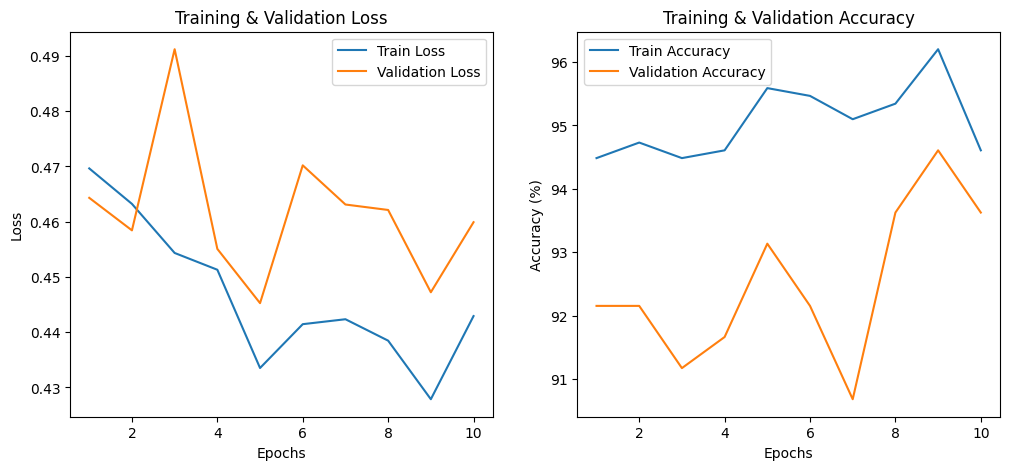

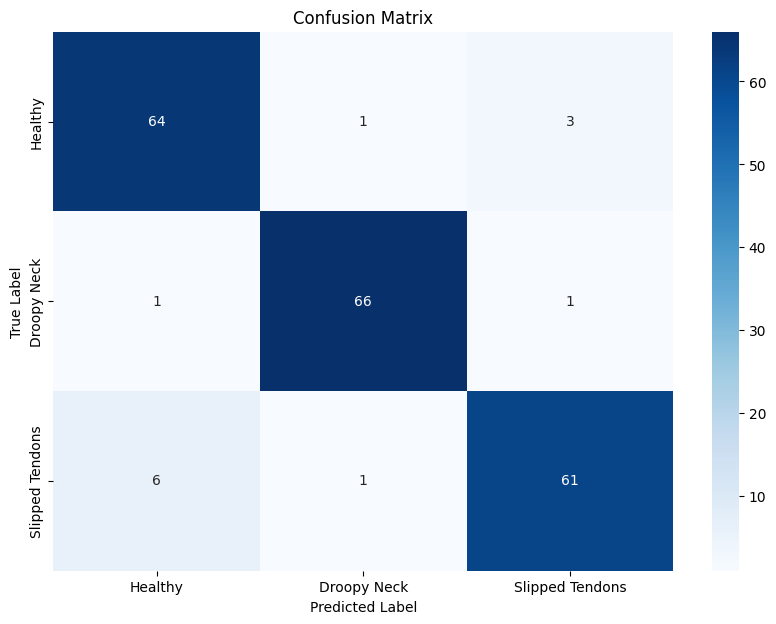

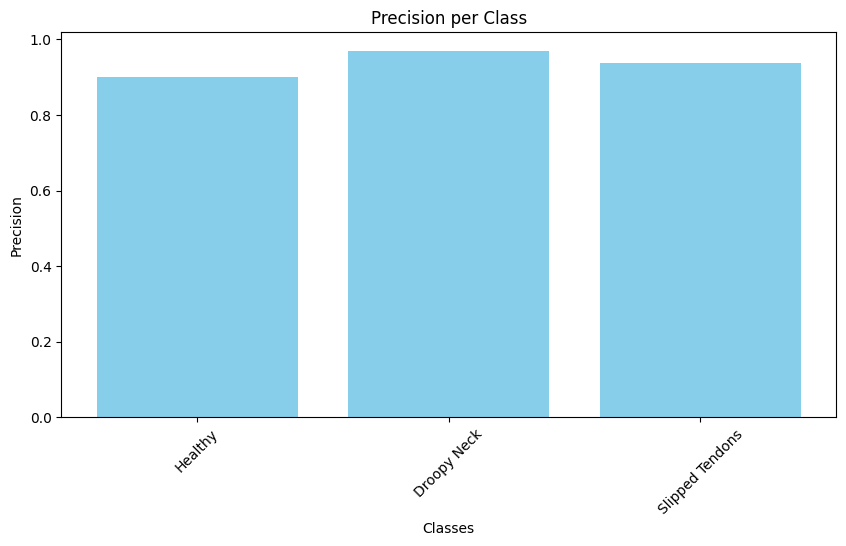

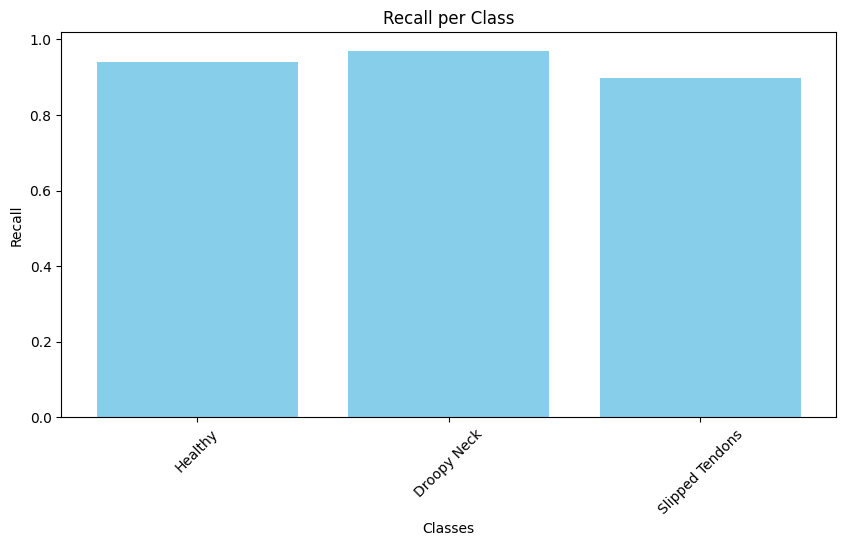

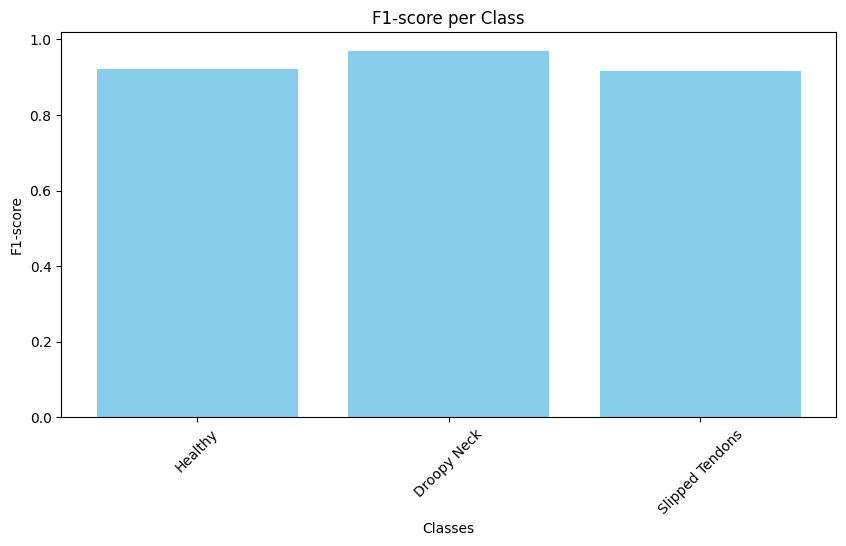

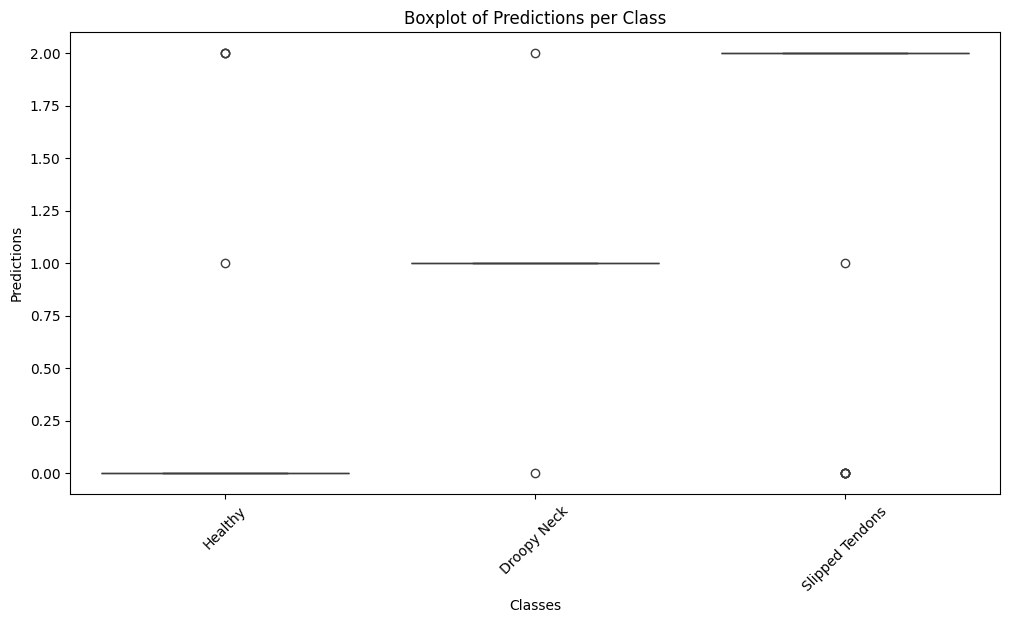

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import torch
import numpy as np

class_names=["Healthy", "Droopy Neck", "Slipped Tendons"]

def plot_training_metrics(history):
    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(12, 5))

    # Plot training & validation loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], label='Train Loss')
    plt.plot(epochs, history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training & Validation Loss')
    plt.legend()

    # Plot training & validation accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], label='Train Accuracy')
    plt.plot(epochs, history['val_acc'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.title('Training & Validation Accuracy')
    plt.legend()

    plt.show()

def plot_confusion_matrix(model, val_loader, device, class_names):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1).cpu().numpy()
            labels = labels.cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels)

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()

def plot_classification_metrics(model, val_loader, device, class_names):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1).cpu().numpy()
            labels = labels.cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels)

    report = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)

    metrics = ['precision', 'recall', 'f1-score']
    for metric in metrics:
        plt.figure(figsize=(10, 5))
        values = [report[class_name][metric] for class_name in class_names]
        plt.bar(class_names, values, color='skyblue')
        plt.xlabel('Classes')
        plt.ylabel(metric.capitalize())
        plt.title(f'{metric.capitalize()} per Class')
        plt.xticks(rotation=45)
        plt.show()

def plot_boxplot_per_class(model, val_loader, device, class_names):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1).cpu().numpy()
            labels = labels.cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels)

    data = {class_name: [] for class_name in class_names}
    for label, pred in zip(all_labels, all_preds):
        data[class_names[label]].append(pred)

    plt.figure(figsize=(12, 6))
    sns.boxplot(data=[data[class_name] for class_name in class_names])
    plt.xticks(range(len(class_names)), class_names, rotation=45)
    plt.xlabel('Classes')
    plt.ylabel('Predictions')
    plt.title('Boxplot of Predictions per Class')
    plt.show()

# Call these functions after training is completed
plot_training_metrics(history)
plot_confusion_matrix(model, val_loader, device, class_names)
plot_classification_metrics(model, val_loader, device, class_names)
plot_boxplot_per_class(model, val_loader, device, class_names)


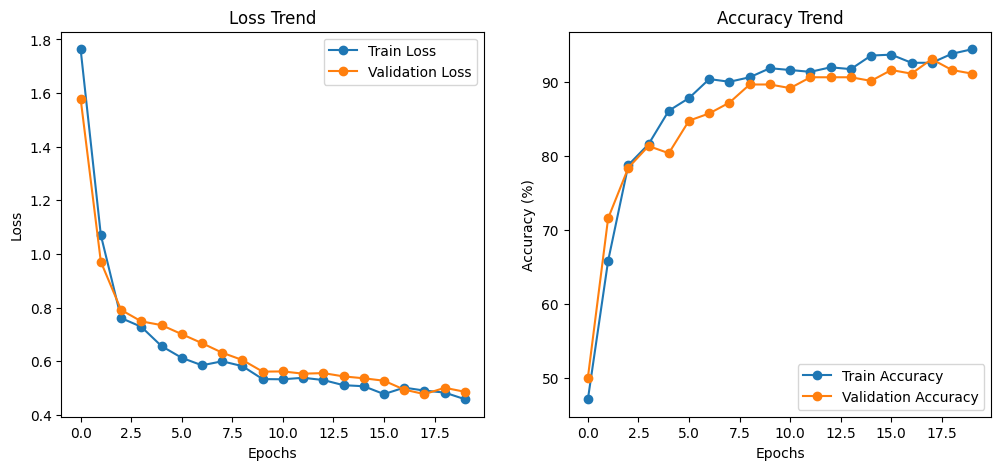

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="Train Loss", marker="o")
plt.plot(history["val_loss"], label="Validation Loss", marker="o")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Trend")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history["train_acc"], label="Train Accuracy", marker="o")
plt.plot(history["val_acc"], label="Validation Accuracy", marker="o")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Trend")
plt.legend()

plt.show()


In [ ]:
def evaluate_model(model, val_loader):
    y_true, y_pred = [], []
    model.eval()
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1).cpu().numpy()
            y_pred.extend(preds)
            y_true.extend(labels.cpu().numpy())

    print(classification_report(y_true, y_pred, target_names=["Healthy", "Droopy Neck", "Slipped Tendons"]))
evaluate_model(model, val_loader)


                 precision    recall  f1-score   support

        Healthy       0.90      0.90      0.90        68
    Droopy Neck       0.96      0.96      0.96        68
Slipped Tendons       0.88      0.88      0.88        68

       accuracy                           0.91       204
      macro avg       0.91      0.91      0.91       204
   weighted avg       0.91      0.91      0.91       204



In [ ]:
# 9. Calculate FLOPs
# Get a sample input from train_loader (adjust shape as needed)
sample_input, _ = next(iter(train_loader))
sample_input = sample_input.to(device)

# Profile the forward pass FLOPs (multiply-add operations)
flops_forward, _ = profile(model, inputs=(sample_input[:1],))  # Use batch size 1 for simplicity

# Estimate FLOPs per training step (forward + backward)
flops_per_train_step = 2 * flops_forward  # Backward pass ≈ forward pass

# Total FLOPs for training (5 epochs)
num_train_steps = len(train_loader)
num_val_steps = len(val_loader)
total_train_flops = 5 * num_train_steps * flops_per_train_step

# Total FLOPs for evaluation (5 epochs)
total_val_flops = 5 * num_val_steps * flops_forward

# Total FLOPs for the snippet
total_flops = total_train_flops + total_val_flops

print(f"Total FLOPs: {total_flops:.2e}")

total_tflops = total_flops / 1e12
print(f"Total TFLOPs: {total_tflops:.4f}")

# 10. Calculate Inference Speed
# Optional: Warm up the model to mitigate any initial overhead
with torch.no_grad():
    _ = model(sample_input[:1])

    total_inference_time = 0.0
    total_samples = 0

    with torch.no_grad():
        for images, _ in val_loader:
                images = images.to(device)
                       batch_size = images.size(0)
                                start_time = time.time()
                                        _ = model(images)
                                                batch_time = time.time() - start_time
                                                        total_inference_time += batch_time
                                                                total_samples += batch_size

                                                                # Compute average inference time per sample
                                                                avg_inference_time_per_sample = total_inference_time / total_samples
                                                                print(f"Average inference time per sample: {avg_inference_time_per_sample:.6f} seconds")